# ARTI403 - Image Processing
## Lab 2: Digital Image Fundamentals

**Name:** Mohammed Saeed Alamodi | **ID:** 2240009007

This notebook works through the tasks in the *Student Procedural Manual - Lab 2*:
- Image Sampling and Quantization
- Arithmetic Operations
- Sets and Logical Operations
- Task #1: Change sampling/quantization parameters and observe the effects
- Task #2: Arithmetic and set operations on two images

### Setup
Create the `images/` folder and get the sample images used below (`lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`).

In [1]:
import os
import numpy as np
from PIL import Image
from skimage import data

os.makedirs('images', exist_ok=True)

if not os.path.exists('images/cameraman.tif'):
    Image.fromarray(data.camera()).save('images/cameraman.tif')

if not os.path.exists('images/lena_gray_256.tif'):
    Image.fromarray(data.astronaut()[:, :, 0]).resize((256, 256)).save('images/lena_gray_256.tif')

# A = rectangle, B = overlapping circle
size = 300
if not os.path.exists('images/A.png'):
    A = np.zeros((size, size), dtype=np.uint8)
    A[60:240, 60:200] = 255
    Image.fromarray(A).save('images/A.png')

if not os.path.exists('images/B.png'):
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy, r = 190, 150, 95
    circle_mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    B = np.zeros((size, size), dtype=np.uint8)
    B[circle_mask] = 255
    Image.fromarray(B).save('images/B.png')

print('Images ready:', sorted(os.listdir('images')))

Images ready: ['A.png', 'B.png', 'cameraman.tif', 'lena_gray_256.tif']


## Procedural Steps
### 1. Image Sampling and Quantization

**Step #1: Import the libraries**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Step #2: Define Functions**

In [ ]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

**Step #3: Import the image and set the parameters**

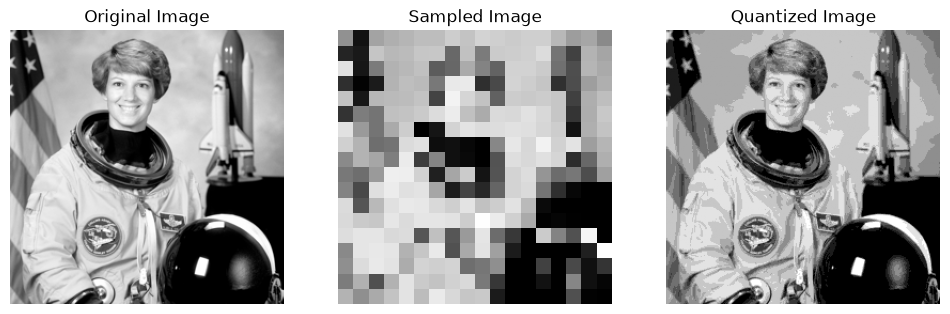

In [4]:
image_path = 'images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

### 2. Arithmetic Operations

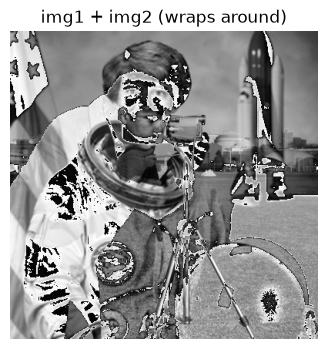

In [5]:
from PIL import Image

img1 = Image.open('images/lena_gray_256.tif')
img2 = Image.open('images/cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)

# uint8 addition wraps around (mod 256) instead of saturating at 255
plt.figure(figsize=(4, 4))
plt.imshow(resultImage, cmap='gray')
plt.title('img1 + img2 (wraps around)')
plt.axis('off')
plt.show()

### 3. Sets and Logical Operations

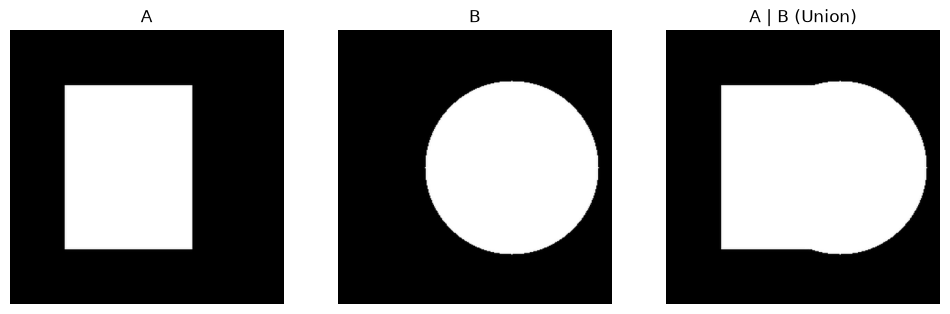

In [6]:
img3 = Image.open('images/A.png')
img4 = Image.open('images/B.png')

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(im3arr, cmap='gray'); axes[0].set_title('A')
axes[1].imshow(im4arr, cmap='gray'); axes[1].set_title('B')
axes[2].imshow(resultImage2, cmap='gray'); axes[2].set_title('A | B (Union)')
for ax in axes:
    ax.axis('off')
plt.show()

## Practical Session Tasks

### Task #1: Change the sampling and quantization parameters and observe the effects.

Below, the original Lena image is sampled with several downsampling factors and quantized with
several grayscale-level counts so the effect of each parameter can be compared directly.

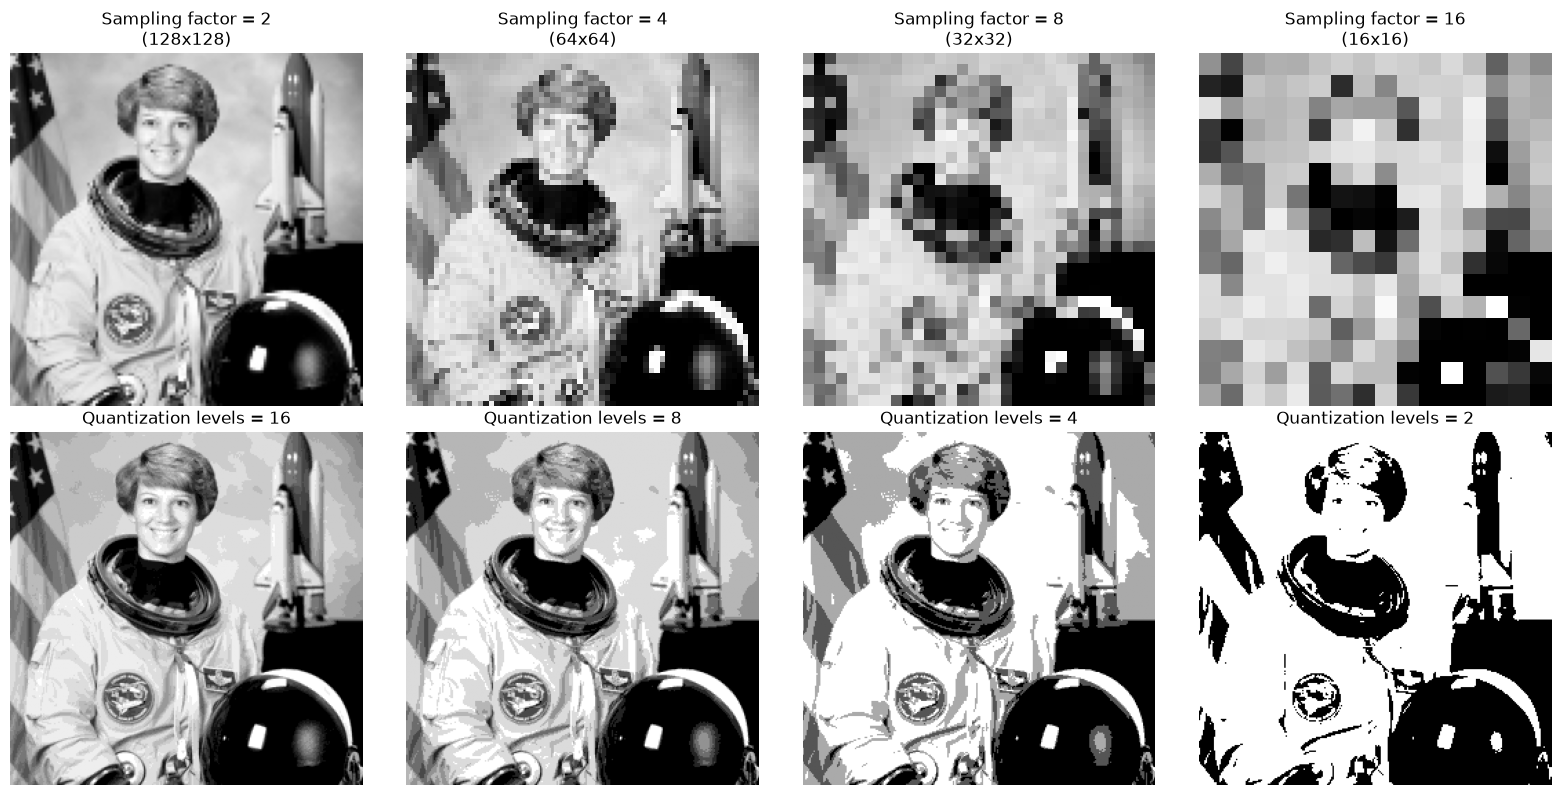

In [7]:
sampling_factors = [2, 4, 8, 16]
quantization_levels_list = [16, 8, 4, 2]

fig, axes = plt.subplots(2, len(sampling_factors), figsize=(4 * len(sampling_factors), 8))

for i, factor in enumerate(sampling_factors):
    sampled = sample_image(original_image, factor)
    axes[0, i].imshow(sampled, cmap='gray')
    axes[0, i].set_title(f'Sampling factor = {factor}\n({sampled.shape[1]}x{sampled.shape[0]})')
    axes[0, i].axis('off')

for i, levels in enumerate(quantization_levels_list):
    quantized = quantize_image(original_image, levels)
    axes[1, i].imshow(quantized, cmap='gray')
    axes[1, i].set_title(f'Quantization levels = {levels}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Observation:** A larger sampling factor removes more pixels between samples, so the image gets blockier and loses detail. Fewer quantization levels means fewer distinct gray shades, so smooth areas start showing visible banding. Both effects get stronger as the parameter moves further from the original (factor = 1, levels = 256).

### Task #2: Read two images, convert them into arrays, and perform the following operations:
1. Subtract two images and display the result.
2. Add one image with a constant value of 175 and display it.
3. Apply the set difference operation on two gray-scale images.
4. Apply the symmetric difference operation on two gray-scale images.
5. Apply the intersection operation on two gray-scale images.

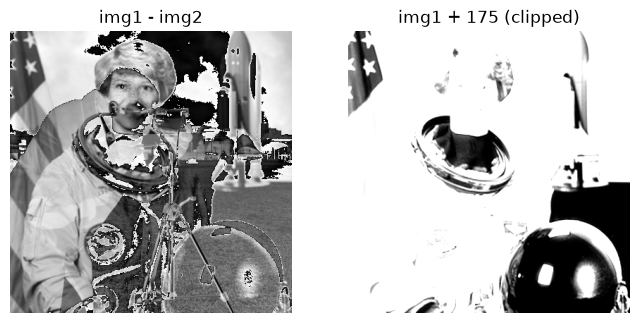

In [8]:
# 1. Subtraction (wraps around below 0, same as uint8 addition above)
subtraction = im1arr - im2arr
sub_image = Image.fromarray(subtraction)

# 2. Add a constant value of 175 to one image (clipped to the valid [0, 255] range)
constant = 175
added_constant = np.clip(im1arr.astype(np.int16) + constant, 0, 255).astype(np.uint8)
const_image = Image.fromarray(added_constant)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sub_image, cmap='gray'); axes[0].set_title('img1 - img2')
axes[1].imshow(const_image, cmap='gray'); axes[1].set_title(f'img1 + {constant} (clipped)')
for ax in axes:
    ax.axis('off')
plt.show()

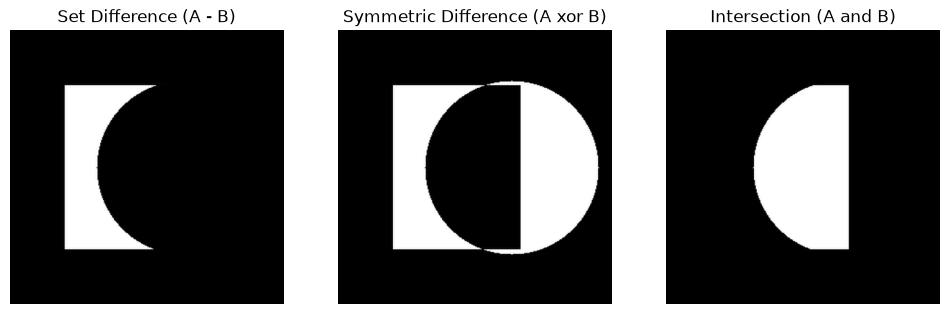

In [9]:
# Set / logical operations on the two gray-scale binary shape images (A, B)

set_difference = im3arr & (~im4arr)          # A \ B : in A but not in B
symmetric_difference = im3arr ^ im4arr        # in A or B but not both (XOR)
intersection = im3arr & im4arr                # in both A and B

diff_image = Image.fromarray(set_difference)
symdiff_image = Image.fromarray(symmetric_difference)
inter_image = Image.fromarray(intersection)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(diff_image, cmap='gray'); axes[0].set_title('Set Difference (A - B)')
axes[1].imshow(symdiff_image, cmap='gray'); axes[1].set_title('Symmetric Difference (A xor B)')
axes[2].imshow(inter_image, cmap='gray'); axes[2].set_title('Intersection (A and B)')
for ax in axes:
    ax.axis('off')
plt.show()